### Considere la base de datos “recursos_humanos.csv” sobre empleados que abandonan una empresa.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

BD = pd.read_csv("recursos_humanos.csv")
BD

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


### El objetivo es analizar porqué los empleados deciden irse con la competencia y éste podría ser un desafío serio para un departamento de recursos humanos, el cual se podría abordar mediante modelos predictivos de Machine Learning. Las variables manejadas son: 

satisfaction_level: Nivel de satisfacción. 

last_evaluation: Puntaje obtenido en la ultima evaluación.

average_montly_hours: Promedio de horas trabajadas al mes.

time_spend_company: Tiempo del usuario en la compañía. 

work_accident: Si el empleado ha tenido algún accidente laboral (1 = Sí, 0 = No).

promotion_last_5years: Si el empleado ha sido promovido en los últimos 5 años.

sales: Departamento donde trabaja. 

salary: Categoría del salario. 

left: Variable a predecir y si el empleado dejó o no la empresa (1 = Sí, 0 = No).

### Cargue la base de datos en Python y asegúrese de re-codificar las variables categóricas de manera pertinente antes de iniciar su análisis (Sugerencia: Use “pd.get_dummies”) 

In [5]:
BD_Dummies = pd.get_dummies(BD[["sales","salary"]])
BD_Dummies

,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,False,False,False,True,False,False,False,False,True
2,False,False,False,False,False,False,False,True,False,False,False,False,True
3,False,False,False,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,False,False,False,False,False,False,False,False,True,False,False,True,False
14995,False,False,False,False,False,False,False,False,True,False,False,True,False
14996,False,False,False,False,False,False,False,False,True,False,False,True,False
14997,False,False,False,False,False,False,False,False,True,False,False,True,False


In [6]:
#Retirar valores para dummies
BD1 = BD.drop(["sales","salary"], axis = 1)

#Normalizacion
BD2 = (BD1 - BD1.min())/(BD1.max() - BD1.min())
BD2

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
0,0.318681,0.265625,0.0,0.285047,0.125,0.0,1.0,0.0
1,0.780220,0.781250,0.6,0.775701,0.500,0.0,1.0,0.0
2,0.021978,0.812500,1.0,0.822430,0.250,0.0,1.0,0.0
3,0.692308,0.796875,0.6,0.593458,0.375,0.0,1.0,0.0
4,0.307692,0.250000,0.0,0.294393,0.125,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
14994,0.340659,0.328125,0.0,0.257009,0.125,0.0,1.0,0.0
14995,0.307692,0.187500,0.0,0.299065,0.125,0.0,1.0,0.0
14996,0.307692,0.265625,0.0,0.219626,0.125,0.0,1.0,0.0
14997,0.021978,0.937500,0.8,0.859813,0.250,0.0,1.0,0.0


In [7]:
BD2.Work_accident = [True if each == 1 else False for each in BD2.Work_accident]
BD2.left = [True if each == 1 else False for each in BD2.left]
BD2.promotion_last_5years = [True if each == 1 else False for each in BD2.promotion_last_5years]
BD2

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
0,0.318681,0.265625,0.0,0.285047,0.125,False,True,False
1,0.780220,0.781250,0.6,0.775701,0.500,False,True,False
2,0.021978,0.812500,1.0,0.822430,0.250,False,True,False
3,0.692308,0.796875,0.6,0.593458,0.375,False,True,False
4,0.307692,0.250000,0.0,0.294393,0.125,False,True,False
...,...,...,...,...,...,...,...,...
14994,0.340659,0.328125,0.0,0.257009,0.125,False,True,False
14995,0.307692,0.187500,0.0,0.299065,0.125,False,True,False
14996,0.307692,0.265625,0.0,0.219626,0.125,False,True,False
14997,0.021978,0.937500,0.8,0.859813,0.250,False,True,False


In [8]:
BD_to_Use = pd.concat([BD2, BD_Dummies], axis=1)
BD_to_Use

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.318681,0.265625,0.0,0.285047,0.125,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,0.780220,0.781250,0.6,0.775701,0.500,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.021978,0.812500,1.0,0.822430,0.250,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,0.692308,0.796875,0.6,0.593458,0.375,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.307692,0.250000,0.0,0.294393,0.125,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.340659,0.328125,0.0,0.257009,0.125,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
14995,0.307692,0.187500,0.0,0.299065,0.125,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
14996,0.307692,0.265625,0.0,0.219626,0.125,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
14997,0.021978,0.937500,0.8,0.859813,0.250,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False


### Mediante un análisis exploratorio de datos determine si esta base de datos está equilibrada o no (de acuerdo a las categorías existentes). 

In [10]:
BD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [11]:
BD.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


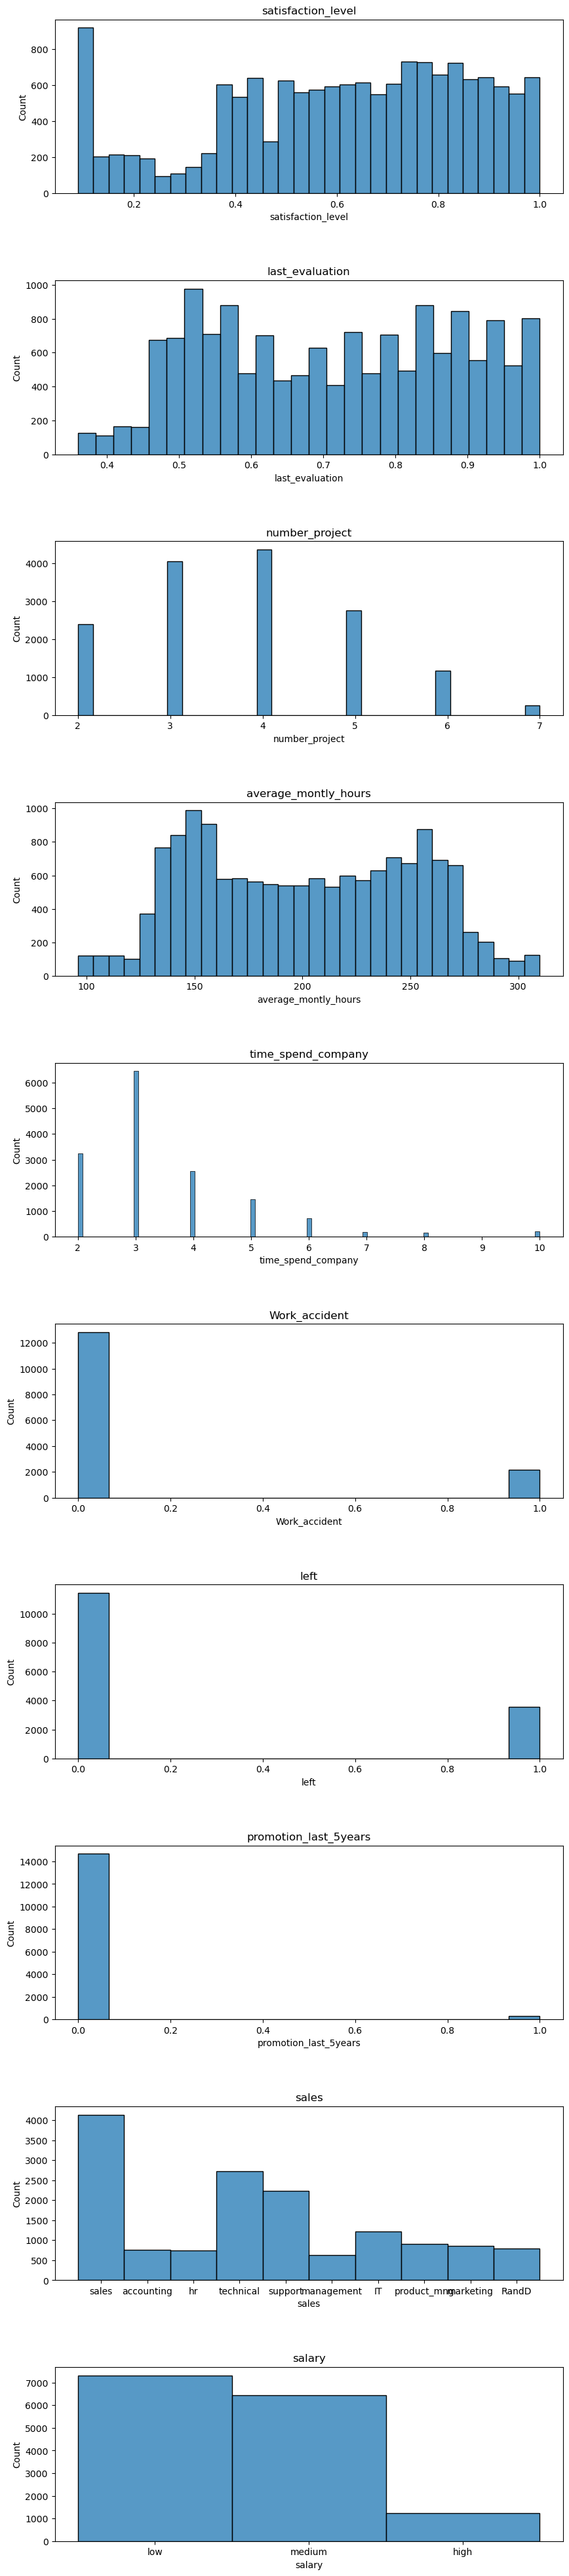

In [12]:
fig, ax = plt.subplots(nrows = len(BD.columns), ncols=1, figsize= (10,50))
fig.subplots_adjust(hspace = 0.5)

for i, col in enumerate(BD.columns):
    sns.histplot(x = col, data = BD, ax=ax[i])
    ax[i].set_title(col)


In [13]:
list(BD['sales'].unique())

['sales',
 'accounting',
 'hr',
 'technical',
 'support',
 'management',
 'IT',
 'product_mng',
 'marketing',
 'RandD']

In [14]:
list(BD["salary"].unique())

['low', 'medium', 'high']

La satisfacción tiene una media del 61.2 %

La puntuación promedio en la última evaluación fue del 71.6%

La cantidad de proyectos promedio por empleados del 3.8

Las horas promedio mensuales son de 201 hrs (aprox. 50.25 hr/sem)

Tiempo del usuario en la compañía promedio 3.49

Accidentes promedio por empleado es de 14% a tenido un accidente laboral

El 23% ha tenido una promoción en los últimos 5 años

Hay un total de 10 departamentos

Y la mayoría tiene un salario bajo

### Use el método de K Vecinos más cercanos para generar un modelo predictivo. Para dicho fin, determine el valor óptimo de K evaluando distintas alternativas:         k = 1, 2, ...., 20 Asegúrese de respaldar su recomendación de la k óptima en base a una tabla que compare en cada caso las diversas precisiones comentadas en esta lección. 


In [17]:
y = BD_to_Use.left.values
x = BD_to_Use.drop(["left"], axis = 1)

In [18]:
# Bases de entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.30, random_state = 1)

In [19]:
# Modelo KNN (K vecinos mas cercanos)
from sklearn.neighbors import KNeighborsClassifier

Max_K = 0
Max_score = 0
New_score = 0

for K in np.arange(1,20,2):
    knn = KNeighborsClassifier(n_neighbors = K)
    knn.fit(x_train,y_train)
    prediction = knn.predict(x_test)

    New_score = knn.score(x_test, y_test)
    
    print("Valor de K: ", K)
    print("Score: ", New_score)
    if New_score > Max_score:
        Max_score = New_score
        Max_K = K

knn = KNeighborsClassifier(n_neighbors = Max_K)
knn.fit(x_train,y_train)
prediction = knn.predict(x_test)
print(" ")
print("Valor de K (Optimo): ", Max_K)
print("Max Score con K optima:", Max_score)

Valor de K:  1
Score:  0.9617777777777777
Valor de K:  3
Score:  0.9453333333333334
Valor de K:  5
Score:  0.9393333333333334
Valor de K:  7
Score:  0.9411111111111111
Valor de K:  9
Score:  0.9324444444444444
Valor de K:  11
Score:  0.9293333333333333
Valor de K:  13
Score:  0.9262222222222222
Valor de K:  15
Score:  0.9253333333333333
Valor de K:  17
Score:  0.9228888888888889
Valor de K:  19
Score:  0.9186666666666666
 
Valor de K (Optimo):  1
Max Score con K optima: 0.9617777777777777


Curiosamente el mayor rango de aciertos fue una K de 1 en este caso, pero sería muy arriesgado dejar un K tan bajo, por lo cual sería recomendable el segundo más elevado K = 3, y el motivo por el cual K fue siempre impar era para evitar empates en el método de KNN.

### Elabore un mapa de calor para la matriz de confusión asociada al valor óptimo de k. Interprete verbalmente cada resultado mostrado en dicha matriz. 
  

In [22]:
#Creacion de la matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, prediction)
cm

array([[3296,  120],
       [  52, 1032]], dtype=int64)

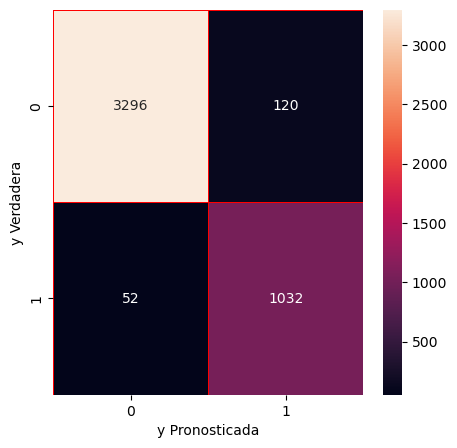

In [23]:
# Visualizacion de la matriz de confusión
import seaborn as sns
f,ax = plt.subplots(figsize = (5, 5))

sns.heatmap(cm, annot = True, linewidths = 0.5, linecolor = "red", fmt = ".0f", ax =ax)
plt.xlabel("y Pronosticada")
plt.ylabel("y Verdadera")

plt.show()

In [24]:
PrecisionQuedarse = cm[0,0]/ (cm[0,0] + cm[1,0])
PrecisionQuedarse

0.984468339307049

In [25]:
PrecisionSalir = cm[1,1]/ (cm[1,1] + cm[0,1])
PrecisionSalir

0.8958333333333334

La predicción mas optima con K=1 tiene una precisión del 98.4% al predecir que se quedarían mientras que tiene un 89.5% de los que se retirarían, pero tiene un ratio general del 96.1% por lo que generalmente es útil, PERO este modelo PODRÍA estar SOBRE-AJUSTADO.

### Obtenga e interprete la gráfica de la curva ROC para el valor óptimo de k.

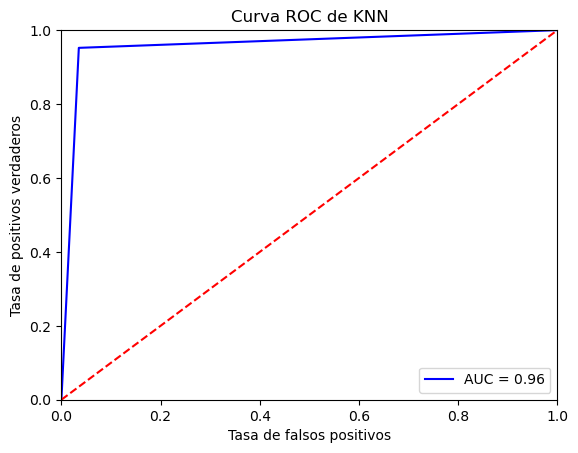

In [28]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_scores = knn.predict_proba(x_test)

fpr, tpr, threshold= roc_curve(y_test, y_scores[:,1])
# fpr = False positive rate
# tpr = True  positive rate

roc_auc = auc(fpr, tpr)

plt.title("Receiver Operation Characteristic")
plt.plot(fpr, tpr, "b", label = "AUC = %0.2f" % roc_auc)
plt.legend(loc= "lower right")
plt.plot([0,1], [0,1], "r--")
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel("Tasa de positivos verdaderos")
plt.xlabel("Tasa de falsos positivos")
plt.title("Curva ROC de KNN")
plt.show()

La K=1 que seria los vecinos utilizados fue el análisis con mayor índice de aciertos (se comparó con K=3 y era mejor K=1 por muy poco), únicamente que es un poco preocupante la posibilidad de que la K puede estar generando un Sobre ajuste, pero como la prueba demostró su “funcionalidad” se descartó eso y se aceptó, al menos hasta tener mas muestras.